<a href="https://colab.research.google.com/github/subhampurohit101-star/CodeAlpha_Iris-Flower-Classification/blob/main/time_series_analyisi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Convert to datetime
df['Month'] = pd.to_datetime(df['Month'])

# Set as index
df.set_index('Month', inplace=True)

# Set frequency (fixes your warning 🔥)
df = df.asfreq('MS')

print(df.head())
print(df.index)   # must show DatetimeIndex

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')


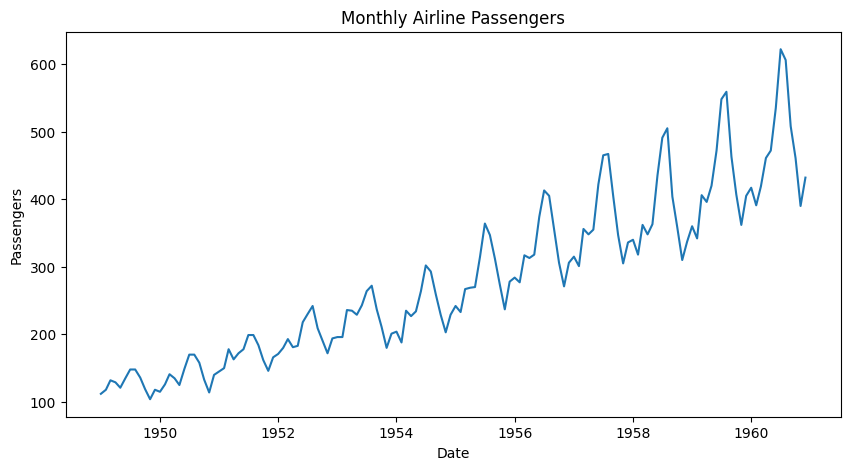

In [4]:
plt.figure(figsize=(10,5))
plt.plot(df)
plt.title("Monthly Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.show()

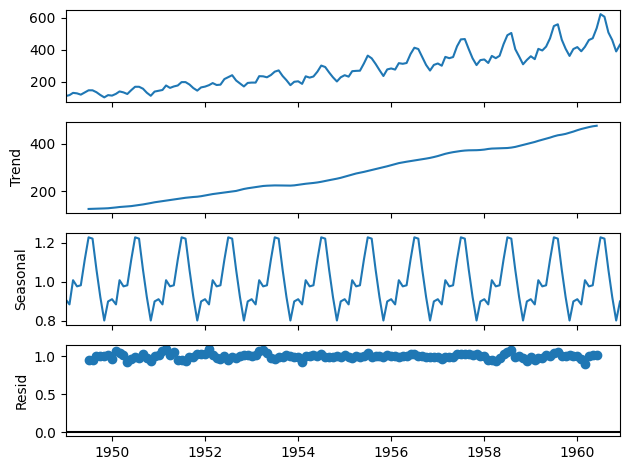

In [5]:
result = seasonal_decompose(df, model='multiplicative')

result.plot()
plt.show()

In [6]:
train = df[:int(len(df)*0.8)]
test = df[int(len(df)*0.8):]

print(len(train), len(test))

115 29


In [7]:
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  115
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -524.549
Date:                Sat, 02 May 2026   AIC                           1061.098
Time:                        06:37:24   BIC                           1077.515
Sample:                    01-01-1949   HQIC                          1067.760
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3558      0.092      3.854      0.000       0.175       0.537
ar.L2         -0.2644      0.109     -2.422      0.015      -0.478      -0.050
ar.L3          0.0847      0.078      1.089      0.2

In [8]:
forecast = model_fit.get_forecast(steps=len(test))

forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

print(forecast_values.head())

1958-08-01    500.902643
1958-09-01    489.904481
1958-10-01    466.349010
1958-11-01    449.296639
1958-12-01    449.565681
Freq: MS, Name: predicted_mean, dtype: float64


In [9]:
rmse = np.sqrt(mean_squared_error(test, forecast_values))
print("RMSE:", rmse)

RMSE: 80.66394527011326


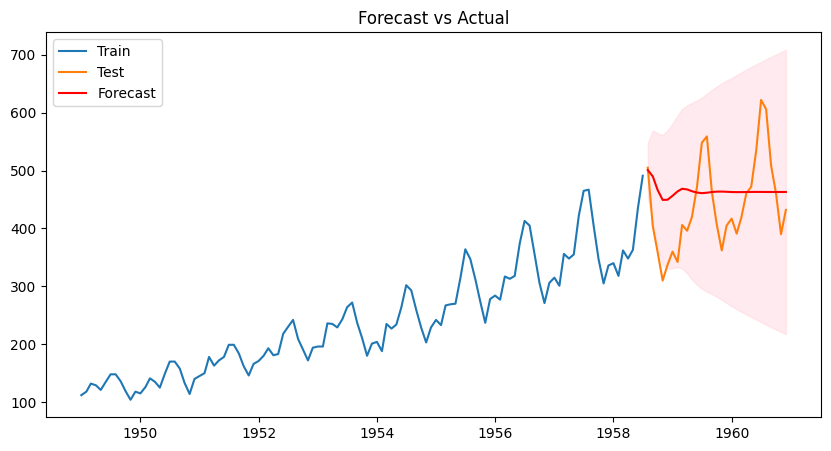

In [10]:
plt.figure(figsize=(10,5))

plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, forecast_values, label='Forecast', color='red')

# Confidence Interval
plt.fill_between(test.index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1],
                 color='pink', alpha=0.3)

plt.legend()
plt.title("Forecast vs Actual")
plt.show()